<a href="https://colab.research.google.com/github/ashleyliang08/IBM-Data-Analyst-PC-Tech-In-Demand-Analysis-Wrangling-and-Visualization-/blob/main/Scrape_App_Reviews_of_Questionai_from_Google_Play_%26_Do_Sentiment_Analysis_using_Python_%26_Focus_On_Bad_Reviews_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Scrape App Reviews of Questionai from Google Play & Do Sentiment Analysis & Focus On Bad Reviews using Python**

##**Import libraries**

In [1]:
!pip install -q google_play_scraper
!pip install -q transformers #for sentiment analysis
!pip install -q plotly-express #data visualization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from google_play_scraper import app,Sort,reviews_all,reviews
import plotly.express as px

##**Scrape data**

In [3]:
# 第一次爬取2000条
result, token = reviews('com.qianfan.aihomework',lang = 'en',country = 'US',sort= Sort.NEWEST,count=2000)
# 第二次爬取额外2000条（总计4000条）
result2, token2 = reviews('com.qianfan.aihomework',lang = 'en',country = 'US',sort= Sort.NEWEST,count=2000, continuation_token=token)
# 合并数据
df = pd.DataFrame(result + result2)
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0cb4fb65-f371-42e5-8fa1-3ee48e594fb9,Leo Moreno,https://play-lh.googleusercontent.com/a/ACg8oc...,That's really good,4,0,None,2025-09-26 03:39:04,None,NaT,None
1,e5f30c04-2c83-40ea-8372-bd4505ac530e,Paris Partynextdoor,https://play-lh.googleusercontent.com/a/ACg8oc...,you don't need to fix that app because it don'...,1,0,None,2025-09-26 02:30:13,"Thank you for your continued support, we're so...",2025-09-26 02:56:06,None
2,cb74cee5-78d4-4c9b-9394-14a30f3df00b,Julienne Mukiwa,https://play-lh.googleusercontent.com/a/ACg8oc...,good 👍🏻😊 Question,5,0,3.3.16,2025-09-25 21:04:34,None,NaT,3.3.16
3,c53f5167-6ec4-46d6-817e-9b7e5b698dca,ivy,https://play-lh.googleusercontent.com/a-/ALV-U...,★★★☆,3,0,3.3.16,2025-09-25 13:37:19,Thank you so much for your feedback. We are ha...,2025-09-26 02:56:21,3.3.16
4,b4223583-2102-4d31-9ff4-9f4624df087f,Muhammad Akbar Ernessantoso,https://play-lh.googleusercontent.com/a-/ALV-U...,banyak iklan asu,1,0,3.0.12,2025-09-25 08:19:56,None,NaT,3.0.12


##**Explore data**

In [4]:
df.drop(columns = ['userImage','reviewCreatedVersion'],inplace = True)

In [5]:
df.shape

(4000, 9)

In [6]:
df.head()

,reviewId,userName,content,score,thumbsUpCount,at,replyContent,repliedAt,appVersion
0,0cb4fb65-f371-42e5-8fa1-3ee48e594fb9,Leo Moreno,That's really good,4,0,2025-09-26 03:39:04,None,NaT,None
1,e5f30c04-2c83-40ea-8372-bd4505ac530e,Paris Partynextdoor,you don't need to fix that app because it don'...,1,0,2025-09-26 02:30:13,"Thank you for your continued support, we're so...",2025-09-26 02:56:06,None
2,cb74cee5-78d4-4c9b-9394-14a30f3df00b,Julienne Mukiwa,good 👍🏻😊 Question,5,0,2025-09-25 21:04:34,None,NaT,3.3.16
3,c53f5167-6ec4-46d6-817e-9b7e5b698dca,ivy,★★★☆,3,0,2025-09-25 13:37:19,Thank you so much for your feedback. We are ha...,2025-09-26 02:56:21,3.3.16
4,b4223583-2102-4d31-9ff4-9f4624df087f,Muhammad Akbar Ernessantoso,banyak iklan asu,1,0,2025-09-25 08:19:56,None,NaT,3.0.12


In [42]:
df['score'].value_counts() #distribution of ratings

,count
score,
5,2205
1,1004
4,311
3,249
2,231


In [37]:
df.rename(columns = {"reviewId":"review_id","score":"rating","thumbsUpCount":"thumbs_up","at":"review_date","replyContent":"developer_response","repliedAt":"response_date","userName":"user_name"})

,review_id,user_name,content,rating,thumbs_up,review_date,developer_response,response_date,appVersion,result,sentiment
0,0cb4fb65-f371-42e5-8fa1-3ee48e594fb9,Leo Moreno,That's really good,4,0,2025-09-26 03:39:04,None,NaT,None,"[{'label': 'POSITIVE', 'score': 0.998491883277...",POSITIVE
1,e5f30c04-2c83-40ea-8372-bd4505ac530e,Paris Partynextdoor,you don't need to fix that app because it don'...,1,0,2025-09-26 02:30:13,"Thank you for your continued support, we're so...",2025-09-26 02:56:06,None,"[{'label': 'NEGATIVE', 'score': 0.999479234218...",NEGATIVE
2,cb74cee5-78d4-4c9b-9394-14a30f3df00b,Julienne Mukiwa,good 👍🏻😊 Question,5,0,2025-09-25 21:04:34,None,NaT,3.3.16,"[{'label': 'POSITIVE', 'score': 0.998700141906...",POSITIVE
3,c53f5167-6ec4-46d6-817e-9b7e5b698dca,ivy,★★★☆,3,0,2025-09-25 13:37:19,Thank you so much for your feedback. We are ha...,2025-09-26 02:56:21,3.3.16,"[{'label': 'POSITIVE', 'score': 0.998486638069...",POSITIVE
4,b4223583-2102-4d31-9ff4-9f4624df087f,Muhammad Akbar Ernessantoso,banyak iklan asu,1,0,2025-09-25 08:19:56,None,NaT,3.0.12,"[{'label': 'POSITIVE', 'score': 0.982715308666...",POSITIVE
...,...,...,...,...,...,...,...,...,...,...,...
3995,11eab687-63e4-4912-8036-a31095a67c82,Callista Michelle Queen,it's just stupid,1,0,2024-08-09 12:19:54,None,NaT,2.8.2,"[{'label': 'NEGATIVE', 'score': 0.999475777149...",NEGATIVE
3996,1e9089da-f3ff-4ad8-a233-52355b1ad669,Sritama Samanta,A great app thx 🙏❤,5,0,2024-08-09 12:14:56,None,NaT,2.8.2,"[{'label': 'POSITIVE', 'score': 0.998845338821...",POSITIVE
3997,1da2bfa7-c514-4217-a766-0e5f95871574,Yuree Alcaid Sanchez,It helps me with everything 👍🏻😆,5,0,2024-08-09 12:08:16,None,NaT,2.8.2,"[{'label': 'POSITIVE', 'score': 0.998834073543...",POSITIVE
3998,db2a74d9-521a-45a3-8ea0-b3efc0128d04,Raquel Arpon,This is great for the high schoolers who is ha...,5,0,2024-08-09 11:52:50,None,NaT,2.8.2,"[{'label': 'POSITIVE', 'score': 0.998741447925...",POSITIVE


##**Sentiment Analysis**

This is a fine-tuned checkpoint of RoBERTa-large (Liu et al. 2019).So I  apply this model directly on this project as follows.
url:https://huggingface.co/siebert/sentiment-roberta-large-english

In [10]:
from transformers import pipeline
sentiment_analysis = pipeline("sentiment-analysis",model="siebert/sentiment-roberta-large-english")
print(sentiment_analysis("I love this!"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9988656044006348}]


**It takes around 27 mintutes to do sentiment analysis↓↓↓↓,so it will be a little  long though.**

In [11]:
df['content'] = df['content'].astype('str')
df['result'] = df['content'].apply(lambda x: sentiment_analysis(x))


In [12]:
df['sentiment'] = df['result'].apply(lambda x: (x[0]['label']))
df['sentiment'].value_counts(normalize = True) #see distribution of sentiment

,proportion
sentiment,
POSITIVE,0.664
NEGATIVE,0.336


##**Foucus on Bad Reviews(Score under 3)**

In [13]:
# 筛选评分≤3的差评
bad_reviews = df[df['score'] <= 3].copy()  # .copy()避免警告

print(f"共抓取{len(df)}条评论，其中差评{len(bad_reviews)}条")

共抓取4000条评论，其中差评1484条


因为评论是英文评论，因此首先下载NLP库中的NLTK（自然语言工具包），再自定义一个预处理函数，在函数中使用NLTK来处理文本，如过滤掉非字符串（即处理缺失值），再统一大小写，接着去除每个token中的标点符号，设置停用词....最后输出3条示例以检查文本是否已经处理干净。

In [33]:
# 1. 先导入nltk并下载缺失的资源（关键步骤）
import nltk
nltk.download('punkt_tab')  # 下载新版本分词必需的资源
nltk.download('stopwords')  # 确保停用词表也已下载

# 2. 重新定义预处理函数
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def preprocess_text(text):
    # 处理非字符串（如None、NaN），避免报错
    if not isinstance(text, str) or text.strip() == "":
        return []
    text = text.lower()  # 转小写
    text = text.translate(str.maketrans('', '', string.punctuation))  # 去标点
    tokens = word_tokenize(text)  # 现在有了punkt_tab，这里不会报错了
    stop_words = set(stopwords.words('english'))  # 英文停用词
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]  # 额外过滤1个字符的无意义词
    return filtered_tokens

# 3. 对差评执行预处理，并将其存储至新的列中
bad_reviews['processed_content'] = bad_reviews['content'].apply(preprocess_text)

# 4. 验证结果（看是否成功生成处理后的词列表）
print("预处理后的前3条差评示例：")
for idx, tokens in bad_reviews['processed_content'].head(3).items():
    print(f"评论{idx}：{tokens[:10]}...")  # 显示每个词列表的前10个词

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


预处理后的前3条差评示例：
评论1：['dont', 'need', 'fix', 'app', 'dont', 'let', 'pick', 'conversation', 'want', 'say']...
评论3：['★★★☆']...
评论4：['banyak', 'iklan', 'asu']...


In [34]:
from collections import Counter

# 合并所有差评的预处理后单词
all_bad_words = []
for tokens in bad_reviews['processed_content']:
    all_bad_words.extend(tokens)

# 统计词频，取Top20
word_counts = Counter(all_bad_words)
print("差评中最常出现的20个关键词：")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}次")

差评中最常出现的20个关键词：
ads: 610次
app: 562次
many: 252次
answers: 237次
wrong: 228次
answer: 210次
good: 185次
question: 177次
every: 131次
ai: 131次
questions: 130次
time: 126次
like: 120次
get: 118次
dont: 113次
even: 107次
much: 105次
ad: 105次
adds: 103次
give: 101次


In [43]:
# 按赞同数降序排列，取Top20
top_disliked = bad_reviews.sort_values('thumbsUpCount', ascending=False).head(20)

print("\n获得最多用户赞同的20条差评（共性问题更明显）：")
for idx, row in top_disliked.iterrows():
    print(f"评分：{row['score']}星 | 赞同数：{row['thumbsUpCount']} | 评论片段：{row['content'][:800]}...")


获得最多用户赞同的20条差评（共性问题更明显）：
评分：1星 | 赞同数：1026 | 评论片段：I used to love this app. It would help with my math homework whenever I was confused as it explained how to solve it. However, after the update, things went down. The ads show up after every scan or question I ask, 30 questions limit only?? And it now completely gives me a different problem, or my question was cut off. Such as "Find the Volume of the Polygon," and it would tell me inequalities, functions, and even bonds like the Biology bonds NOT EVEN MATH RELATED. Photomath is better than this....
评分：1星 | 赞同数：617 | 评论片段：BEWARE!!!!! At 1st this app was great until here the last couple of months I'm always having to despute the extra charge these people charge me EVERY month. I've been getting charged twice every month and when I tried to email their support team the email is not a correct domain. Not sure this app is even worth the headache anymore. Sad because it used to be great....
评分：1星 | 赞同数：456 | 评论片段：DO NOT BUY PREMIUM! before I 

In [17]:
!pip install seaborn
!pip install matplotlib
!pip install seaborn wordcloud

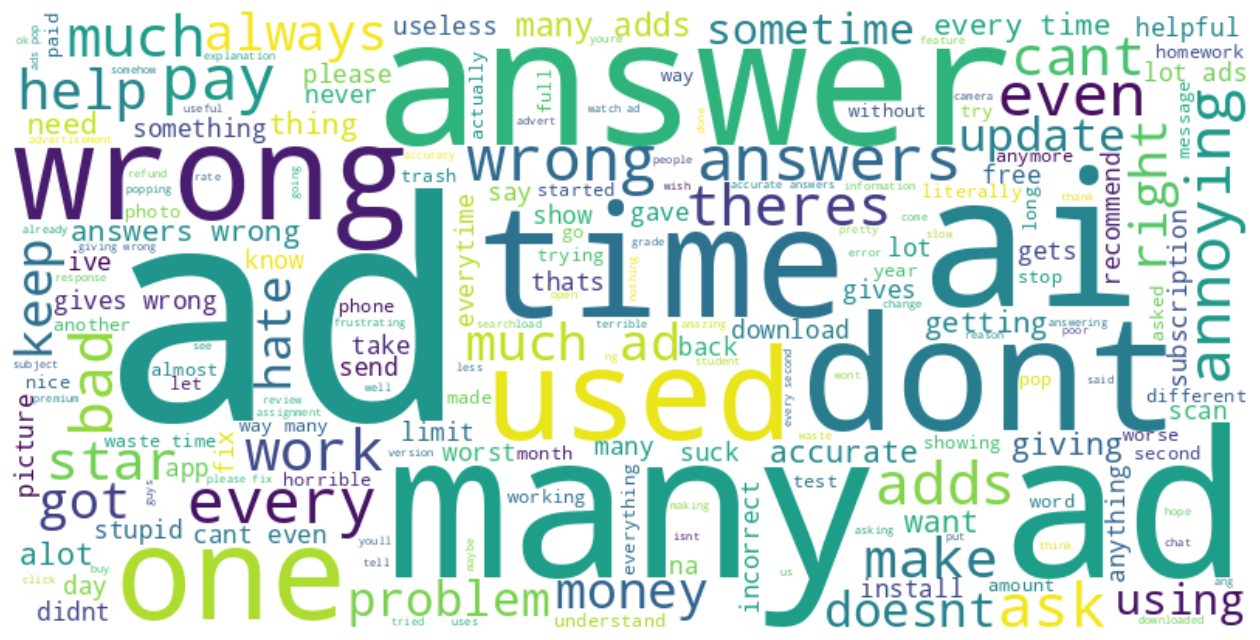

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join the processed words from all bad reviews into a single string
# Filter out 'app' and 'good'
filtered_words = [word for word in all_bad_words if word not in ['app', 'good','answer','great','first','better','still'
,'question','questions','give','use','love','best','really','math','correct','add','im']]
all_words_string = " ".join(filtered_words)


# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words_string)

# Display the word cloud
plt.figure(figsize=(16,9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()